In [ ]:
#########################################################################
########------ Ciencia de Datos e IA Generativa con Python ------########
#########################################################################
# Capacitador: Julio César Bernal Fernández
# email: juliobf08@gmail.com
# Tema : Aplicación de Clustering (Agrupamiento)
# versión: 1.0
#########################################################################

## **Librerías**

In [1]:
# Manipulación y tratatamiendo de los datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# sistema operativo
import warnings
import os

# Modelos de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics

#Librerías Aprendizaje No Supervisado
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
%matplotlib inline

In [12]:
pwd

'/content'

### Archivo 1

In [11]:
file = 'https://raw.githubusercontent.com/AxisAngeles/Smart_Data_DS_AI/main/Empresas_Reactiva_Peru.xlsx'

df = pd.read_excel(file)# df =pd.read_excel('Empresas_Reactiva_Peru.xlsx')
#df = pd.DataFrame(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71552 entries, 0 to 71551
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RUC              71552 non-null  float64
 1   NOMBRE_EMPRESA   71552 non-null  object 
 2   SECTOR           71552 non-null  object 
 3   BANCO            71552 non-null  object 
 4   MONTO_PRESTAMO   71552 non-null  float64
 5   FLG_1MM          71552 non-null  int64  
 6   MONTO_COBERTURA  71552 non-null  float64
 7   DEPARTAMENTO     71552 non-null  object 
dtypes: float64(3), int64(1), object(4)
memory usage: 4.4+ MB


In [13]:
df.head()

,RUC,NOMBRE_EMPRESA,SECTOR,BANCO,MONTO_PRESTAMO,FLG_1MM,MONTO_COBERTURA,DEPARTAMENTO
0,1.000001e+10,HERTER REATEGUI MORI,INDUSTRIA MANUFACTURERA,CRÉDITO,10724.0,0,10509.52,UCAYALI
1,1.000003e+10,RANDOLFO SANCHEZ SANCHEZ,OTROS SERVICIOS,CRÉDITO,6843.0,0,6706.14,UCAYALI
2,1.000005e+10,DAVID RAMON FLORES RAMIREZ,COMERCIO,CRÉDITO,12154.0,0,11910.92,UCAYALI
3,1.000005e+10,BETTY RUIZ DELGADO,COMERCIO,CRÉDITO,5197.0,0,5093.06,UCAYALI
4,1.000006e+10,NILTON RENGIFO MURRIETA,COMERCIO,BANCO BBVA PERU,50000.0,0,47500.00,LORETO


In [14]:
df.shape

(71552, 8)

### Archivo 2

In [16]:
file = 'https://raw.githubusercontent.com/AxisAngeles/Smart_Data_DS_AI/main/Income.xlsx'

# df1 = pd.read_excel('Income.xlsx')
df1 = pd.read_excel(file)
#df1 = pd.DataFrame(df1)
#df1.head(n=10)
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71552 entries, 0 to 71551
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RUC     71552 non-null  float64
 1   INCOME  71552 non-null  float64
dtypes: float64(2)
memory usage: 1.1 MB


In [17]:
df1.head()

,RUC,INCOME
0,1.000001e+10,2.059190e+06
1,1.000003e+10,3.092363e+06
2,1.000005e+10,3.787848e+06
3,1.000005e+10,1.619668e+06
4,1.000006e+10,1.558272e+07


### Unir ambos DFs

In [18]:
df2 = pd.merge(df, df1, on='RUC')

In [19]:
df2.head()

,RUC,NOMBRE_EMPRESA,SECTOR,BANCO,MONTO_PRESTAMO,FLG_1MM,MONTO_COBERTURA,DEPARTAMENTO,INCOME
0,1.000001e+10,HERTER REATEGUI MORI,INDUSTRIA MANUFACTURERA,CRÉDITO,10724.0,0,10509.52,UCAYALI,2.059190e+06
1,1.000003e+10,RANDOLFO SANCHEZ SANCHEZ,OTROS SERVICIOS,CRÉDITO,6843.0,0,6706.14,UCAYALI,3.092363e+06
2,1.000005e+10,DAVID RAMON FLORES RAMIREZ,COMERCIO,CRÉDITO,12154.0,0,11910.92,UCAYALI,3.787848e+06
3,1.000005e+10,BETTY RUIZ DELGADO,COMERCIO,CRÉDITO,5197.0,0,5093.06,UCAYALI,1.619668e+06
4,1.000006e+10,NILTON RENGIFO MURRIETA,COMERCIO,BANCO BBVA PERU,50000.0,0,47500.00,LORETO,1.558272e+07


In [20]:
# Para que todo el DF muestre los números a 2 decimales
pd.set_option('display.float_format', '{:.2f}'.format)

In [21]:
#CREAMOS EL % DE COBERTURA:

df2['PORCENTAJE_COBERTURA'] = df2['MONTO_COBERTURA'] / df2['MONTO_PRESTAMO']

In [22]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71552 entries, 0 to 71551
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   RUC                   71552 non-null  float64
 1   NOMBRE_EMPRESA        71552 non-null  object 
 2   SECTOR                71552 non-null  object 
 3   BANCO                 71552 non-null  object 
 4   MONTO_PRESTAMO        71552 non-null  float64
 5   FLG_1MM               71552 non-null  int64  
 6   MONTO_COBERTURA       71552 non-null  float64
 7   DEPARTAMENTO          71552 non-null  object 
 8   INCOME                71552 non-null  float64
 9   PORCENTAJE_COBERTURA  71552 non-null  float64
dtypes: float64(5), int64(1), object(4)
memory usage: 5.5+ MB


In [23]:
df2.head()

,RUC,NOMBRE_EMPRESA,SECTOR,BANCO,MONTO_PRESTAMO,FLG_1MM,MONTO_COBERTURA,DEPARTAMENTO,INCOME,PORCENTAJE_COBERTURA
0,10000006209.00,HERTER REATEGUI MORI,INDUSTRIA MANUFACTURERA,CRÉDITO,10724.00,0,10509.52,UCAYALI,2059189.99,0.98
1,10000027443.00,RANDOLFO SANCHEZ SANCHEZ,OTROS SERVICIOS,CRÉDITO,6843.00,0,6706.14,UCAYALI,3092362.83,0.98
2,10000046383.00,DAVID RAMON FLORES RAMIREZ,COMERCIO,CRÉDITO,12154.00,0,11910.92,UCAYALI,3787848.08,0.98
3,10000051891.00,BETTY RUIZ DELGADO,COMERCIO,CRÉDITO,5197.00,0,5093.06,UCAYALI,1619668.13,0.98
4,10000059205.00,NILTON RENGIFO MURRIETA,COMERCIO,BANCO BBVA PERU,50000.00,0,47500.00,LORETO,15582722.06,0.95


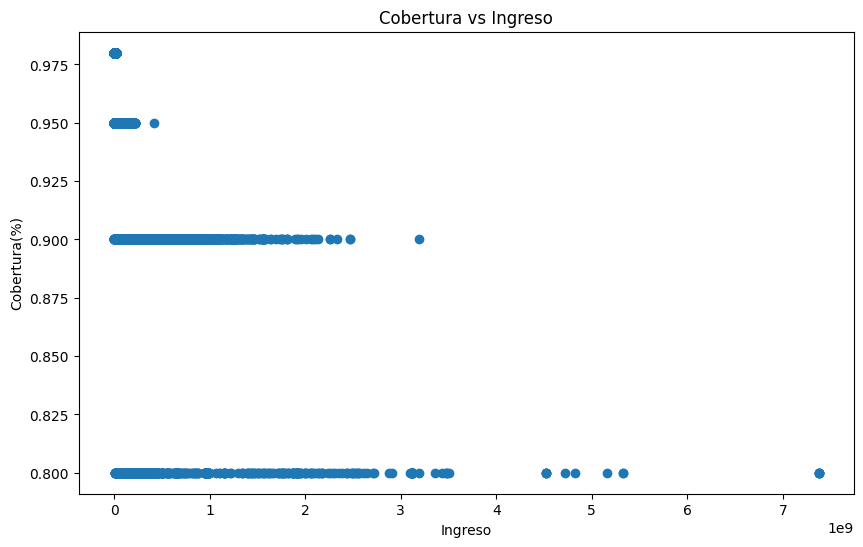

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(y = df2['PORCENTAJE_COBERTURA'], x = df2['INCOME'])
plt.title("Cobertura vs Ingreso")
plt.xlabel("Ingreso")
plt.ylabel("Cobertura(%)")
plt.show()

### Correlación entre las variables del modelo

In [27]:
corr = df2[['MONTO_PRESTAMO','MONTO_COBERTURA','INCOME','PORCENTAJE_COBERTURA']].corr().round(3)
corr

,MONTO_PRESTAMO,MONTO_COBERTURA,INCOME,PORCENTAJE_COBERTURA
MONTO_PRESTAMO,1.00,1.00,0.56,-0.73
MONTO_COBERTURA,1.00,1.00,0.57,-0.74
INCOME,0.56,0.57,1.00,-0.48
PORCENTAJE_COBERTURA,-0.73,-0.74,-0.48,1.00


**Existe una coorleación del 100% entre Monto_Préstamo y Monto_Cobertura**

_Por lo tanto, debemos elegir entre una u otra variable_

---


In [28]:
X=np.array(df2[['PORCENTAJE_COBERTURA','MONTO_PRESTAMO','INCOME']])
X.shape

(71552, 3)

Pasos a seguir para clusterizar un caso de uso:

1.- Identificar las variables numéricas que van a ser tomadas en cuenta (no flags, no variables de texto, no variables de identificación, entre otras)

2.- Podemos revisar la posibilidad de añadir o crear nuevas variables numéricas que tengan sentido o coherencia en el análisis

3.- Validar la correlación de variables para determinar cuáles deben ser elegidas en la clusterización.

4.- Elegir las variables numéricas que se tomarán en cuenta en el análisis.

5.- Iterar el algoritmo en un rango de opciones y en base al resultado y nuestro criterio, determinar el número de cluster.

6.- Aplicar el algoritmo KMeans y generar los cluster para todos los registros de la tabla.

6.- Almacenar los cluster en un dataframe y concatenarlos con los registros originales.

7.- Exportar la base de datos con la etiqueta de clúster para los análisis correspondientes.

## **Clúster con KMeans**

[KMeans(n_clusters=1), KMeans(n_clusters=2), KMeans(n_clusters=3), KMeans(n_clusters=4), KMeans(n_clusters=5), KMeans(n_clusters=6), KMeans(n_clusters=7), KMeans(), KMeans(n_clusters=9)]
[2.516715622352779e+21, 1.0007770699127983e+21, 5.3992320166204034e+20, 3.783513135091805e+20, 2.5080296759329705e+20, 1.5278236404447055e+20, 1.089134278118769e+20, 8.805353304658643e+19, 7.020678499197058e+19]


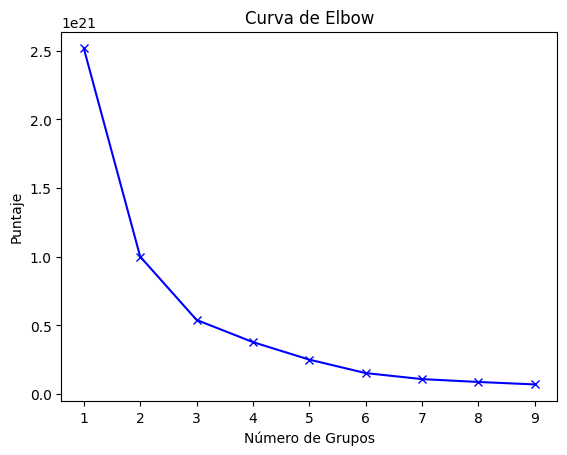

In [29]:
# Curva de codo

# Generamos el modelo de 1 a 9 clústers
Nc = range(1,10)
kmeans = [KMeans(n_clusters=i) for i in Nc]
print(kmeans)

# Inertia Score
score = [kmeans[i].fit(X).inertia_ for i in range(len(kmeans))]
print(score)

# Gráfica
plt.plot(Nc,score, 'bx-')
plt.xlabel('Número de Grupos')
plt.ylabel('Puntaje')
plt.title('Curva de Elbow')
plt.show()

In [30]:
num_clusters = 4

In [31]:
data=df2[['PORCENTAJE_COBERTURA','MONTO_PRESTAMO','INCOME']]

In [32]:
#Segmentación de KMeans
kmeans = KMeans(init='k-means++', n_clusters=num_clusters, n_init=10)
kmeans.fit(data)

KMeans(n_clusters=4, n_init=10)

In [33]:
pd.DataFrame(kmeans.predict(data)).value_counts()

,count
0,
0,67885
3,3110
1,457
2,100


**Se agruparon demasiadas empresas en el Clúster 0**

_Hagamos una comparación objetiva_

---


## **Comparar con Silhouette_score**

In [40]:
from sklearn.metrics import silhouette_score

In [41]:
def form_cluster(x,k):
  no_clusters = k
  model = KMeans(n_clusters=no_clusters, init='k-means++', n_init=10,random_state = 123)
  model.fit(x)
  labels = model.labels_
  print(labels)

  # Cacluate the silhouette score
  sh_score = silhouette_score(x,labels)
  print(sh_score)
  return sh_score

In [42]:
prediction = kmeans.predict(data)

In [43]:
prediction

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [44]:
form_cluster(data,4)

[0 0 0 ... 0 0 0]
0.8739052086427619


np.float64(0.8739052086427619)

In [45]:
form_cluster(data,5)

[0 0 0 ... 0 0 0]
0.8336591757427821


np.float64(0.8336591757427821)

In [46]:
model = KMeans(n_clusters=4,init='k-means++', n_init=10,random_state = 123 )
model.fit(X)

KMeans(n_clusters=4, n_init=10, random_state=123)

In [47]:
prediction= model.predict(X)

In [48]:
prediction

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [49]:
pronosseg = pd.DataFrame(prediction)

In [50]:
pronosseg.columns=['Segmento']

In [51]:
pronosseg.head(20)

,Segmento
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [52]:
pronosseg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71552 entries, 0 to 71551
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Segmento  71552 non-null  int32
dtypes: int32(1)
memory usage: 279.6 KB


In [53]:
data = data[['MONTO_PRESTAMO','INCOME','PORCENTAJE_COBERTURA']]
data.head()

,MONTO_PRESTAMO,INCOME,PORCENTAJE_COBERTURA
0,10724.00,2059189.99,0.98
1,6843.00,3092362.83,0.98
2,12154.00,3787848.08,0.98
3,5197.00,1619668.13,0.98
4,50000.00,15582722.06,0.95


In [54]:
res1=pd.concat([data,pronosseg],axis=1).groupby(['Segmento']).mean()
#res1.style.applymap(lambda x: 'background-color : yellow' if x>res1.iloc[0,0] else '')
res1

,MONTO_PRESTAMO,INCOME,PORCENTAJE_COBERTURA
Segmento,,,
0,230206.83,23421624.65,0.95
1,5350686.17,1321159188.79,0.86
2,9180699.73,3381509479.17,0.80
3,1850980.27,346892082.43,0.89


In [55]:
pronosseg.head()

,Segmento
0,0
1,0
2,0
3,0
4,0


In [56]:
data_final=pd.concat([df2,pronosseg],axis=1)

In [57]:
data_final.head()

,RUC,NOMBRE_EMPRESA,SECTOR,BANCO,MONTO_PRESTAMO,FLG_1MM,MONTO_COBERTURA,DEPARTAMENTO,INCOME,PORCENTAJE_COBERTURA,Segmento
0,10000006209.00,HERTER REATEGUI MORI,INDUSTRIA MANUFACTURERA,CRÉDITO,10724.00,0,10509.52,UCAYALI,2059189.99,0.98,0
1,10000027443.00,RANDOLFO SANCHEZ SANCHEZ,OTROS SERVICIOS,CRÉDITO,6843.00,0,6706.14,UCAYALI,3092362.83,0.98,0
2,10000046383.00,DAVID RAMON FLORES RAMIREZ,COMERCIO,CRÉDITO,12154.00,0,11910.92,UCAYALI,3787848.08,0.98,0
3,10000051891.00,BETTY RUIZ DELGADO,COMERCIO,CRÉDITO,5197.00,0,5093.06,UCAYALI,1619668.13,0.98,0
4,10000059205.00,NILTON RENGIFO MURRIETA,COMERCIO,BANCO BBVA PERU,50000.00,0,47500.00,LORETO,15582722.06,0.95,0


In [58]:
data_final['Segmento'].value_counts()

,count
Segmento,
0,67885
3,3110
1,457
2,100


In [59]:
#EXPORTAR BASE
data_final.to_csv("resultados_test.csv",index=False, sep = '|')

In [60]:
data_final.to_excel("resultados_test_1.xlsx",index=False)